# Vision Transformer Autoencoder (không masking) cho ảnh vệ tinh Himawari-8 — phiên bản PyTorch

Notebook này là bản chuyển đổi từ notebook **CNN Convolutional Autoencoder (CAE) — PyTorch** trước đó. Theo đúng yêu cầu, **chỉ phần kiến trúc model (Encoder/Decoder) được thay đổi**; toàn bộ phần còn lại (đường dẫn dữ liệu, tiền xử lý, `Dataset`/`DataLoader`, training loop, loss (MSE + L1 + L2), evaluation (MSE/MAE/PSNR/SSIM), visualization, checkpoint, save/load) được **giữ nguyên logic**.

## Điểm khác biệt duy nhất so với bản CNN

- **Kiến trúc Encoder/Decoder**: từ `Conv2D`/`MaxPooling2D`/`ConvTranspose2D` (CNN) → **Vision Transformer** (patch embedding + positional embedding + Multi-Head Self-Attention + MLP, dùng `LayerNorm`).
- **Lấy cảm hứng từ Masked Autoencoder (MAE)** ở luồng Encoder–Decoder bất đối xứng (decoder nhỏ hơn encoder), nhưng **KHÔNG dùng masking**: không Random Masking, không Mask Ratio, không Mask Token, không `ids_keep`/`ids_restore`. **Toàn bộ 1024 patch của ảnh 512×512 được đưa vào Encoder và được Decoder tái tạo lại đầy đủ.**
- `BATCH_SIZE` giảm từ `64` xuống `16` — lý do kỹ thuật được giải thích chi tiết ở phần Configuration (self-attention giữa 1024 patch tốn nhiều VRAM hơn nhiều so với Conv2D).
- Mọi hyperparameter khác (`EPOCHS`, `LEARNING_RATE`, `L1_LAMBDA`, `L2_WEIGHT_DECAY`, `EARLY_STOPPING_PATIENCE`), toàn bộ pipeline dữ liệu, loss, và phương pháp đánh giá **giữ nguyên như bản CNN**.

**Pipeline tổng quát (mới):**

```
Ảnh gốc (512×512×1)
  → Patchify (1024 patch, mỗi patch 16×16×1)
  → Patch Embedding + Positional Embedding
  → Transformer Encoder (toàn bộ 1024 patch, không masking)
  → Latent Representation (1024 token)
  → Transformer Decoder
  → Reconstruction Head + Unpatchify
  → Ảnh tái tạo (512×512×1)
```


## 1. Import libraries

Giữ nguyên toàn bộ thư viện của bản CNN — chỉ dùng PyTorch để xây dựng và train model (không TensorFlow/Keras). `scikit-learn` dùng để chia train/validation, `scikit-image` dùng để tính SSIM/PSNR, `pytorch-msssim` để tính SSIM nhanh trên GPU trong lúc validation, `torch.cuda.amp` cho Mixed Precision Training. Không cần thêm thư viện nào mới cho phần Transformer vì `nn.MultiheadAttention` và `nn.LayerNorm` đã có sẵn trong `torch.nn`.

In [1]:
import os
import glob
import random

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

# pytorch-msssim: tính SSIM trực tiếp trên tensor GPU (bằng conv2d + Gaussian
#   kernel), không cần chuyển .cpu().numpy() như skimage -> nhanh hơn nhiều khi
#   phải tính SSIM lặp lại mỗi epoch. Cài đặt: pip install pytorch-msssim
from pytorch_msssim import ssim as ssim_gpu

# Automatic Mixed Precision - tính phần lớn phép toán ở FP16 thay vì FP32
from torch.cuda.amp import autocast, GradScaler

# Cố định seed để kết quả có thể tái lập (reproducible)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


## 2. Configuration

Khai báo đường dẫn dataset, kích thước ảnh, và các **hyperparameter**.

### Hyperparameter giữ nguyên từ bản CNN

- **`IMG_SIZE = 512`**, **`CHANNELS = 1`**: không đổi.
- **`EPOCHS = 100`**, **`LEARNING_RATE = 1e-3`**, **`L1_LAMBDA`**, **`L2_WEIGHT_DECAY`**, **`EARLY_STOPPING_PATIENCE = 20`**: giữ nguyên giá trị — không có lý do kỹ thuật bắt buộc phải đổi các giá trị này khi chuyển sang Transformer.

### Hyperparameter mới cho kiến trúc Vision Transformer

- **`PATCH_SIZE = 16`**: kích thước mỗi patch vuông. Với `IMG_SIZE = 512` → `NUM_PATCHES = (512/16)² = 1024` patch, mỗi patch có `16×16×1 = 256` giá trị pixel (`PATCH_DIM`).
- **`EMBED_DIM = 384`**: số chiều embedding của Encoder (tương đương quy mô "ViT-Small"). Đủ lớn để học biểu diễn ảnh vệ tinh, nhưng không quá lớn để tránh thiếu VRAM.
- **`ENCODER_DEPTH = 8`**: số Transformer block trong Encoder.
- **`NUM_HEADS = 6`**: số head trong Multi-Head Self-Attention của Encoder (`EMBED_DIM` phải chia hết cho `NUM_HEADS`: `384/6 = 64`).
- **`MLP_RATIO = 4.0`**: tỉ lệ mở rộng chiều ẩn trong khối MLP/Feed-Forward của mỗi Transformer block (`hidden_dim = EMBED_DIM × MLP_RATIO`).
- **`DECODER_EMBED_DIM = 192`**, **`DECODER_DEPTH = 4`**, **`DECODER_NUM_HEADS = 6`**: Decoder cố tình nhỏ hơn Encoder nhiều lần (đúng tinh thần bất đối xứng Encoder–Decoder của MAE), vì công việc chính (học biểu diễn) đã được Encoder đảm nhiệm; Decoder chỉ cần đủ khả năng ánh xạ latent trở lại pixel.

### Thay đổi bắt buộc: `BATCH_SIZE`

`BATCH_SIZE` giảm từ **`64`** (bản CNN) xuống **`16`**. Lý do kỹ thuật:

- CNN Autoencoder cũ chỉ có **~1.67 triệu tham số**, và chi phí bộ nhớ của Conv2D/MaxPooling tăng **tuyến tính** theo số pixel.
- Vision Transformer Autoencoder mới có **~16.8 triệu tham số** (gấp ~10 lần), và quan trọng hơn: **Self-Attention có chi phí bộ nhớ tăng theo bậc hai (O(N²))** với `N = 1024` patch — tại mỗi Encoder block, ma trận attention có kích thước `(B, NUM_HEADS, 1024, 1024)`. Với `BATCH_SIZE = 64` và 8 block Encoder, tổng VRAM cần cho activation (để backpropagation) vượt quá khả năng của hầu hết GPU phổ thông.
- Giữ `BATCH_SIZE = 16` (kết hợp AMP ở phần Training) giúp notebook chạy được trên GPU phổ thông (~8GB VRAM trở lên). Nếu máy có VRAM lớn hơn (ví dụ ≥16GB), có thể tăng dần lên 24/32 và theo dõi qua `nvidia-smi`; nếu vẫn gặp `CUDA out of memory`, hạ xuống 8.

Toàn bộ cấu trúc thư mục dataset, đường dẫn, và cách tự động phát hiện GPU giữ nguyên như bản CNN.

In [2]:
# --- Đường dẫn dataset (giữ nguyên như bản CNN) ---
DATASET_DIR = "dataset"  # thư mục chứa 2 thư mục con: train/ và test/
TRAIN_DIR = os.path.join(DATASET_DIR, "train")
TEST_DIR = os.path.join(DATASET_DIR, "test")

# --- Kích thước ảnh (giữ nguyên) ---
IMG_SIZE = 512
CHANNELS = 1

# --- Hyperparameter kiến trúc Vision Transformer (mới) ---
PATCH_SIZE = 16
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2          # 1024
PATCH_DIM = PATCH_SIZE * PATCH_SIZE * CHANNELS        # 256

EMBED_DIM = 384            # chiều embedding của Encoder (quy mô ViT-Small)
ENCODER_DEPTH = 8          # số Transformer block trong Encoder
NUM_HEADS = 6              # số attention head trong Encoder (384 / 6 = 64 mỗi head)
MLP_RATIO = 4.0            # hệ số mở rộng chiều ẩn trong MLP của mỗi block

DECODER_EMBED_DIM = 192    # Decoder nhỏ hơn Encoder nhiều lần (bất đối xứng kiểu MAE)
DECODER_DEPTH = 4
DECODER_NUM_HEADS = 6

# --- Hyperparameter training (giữ nguyên từ bản CNN, trừ BATCH_SIZE) ---
BATCH_SIZE = 16   # (sửa) giảm từ 64 -> 16: self-attention trên 1024 patch tốn
                  #   VRAM theo O(N^2), khác với Conv2D vốn tốn VRAM tuyến tính -
                  #   xem giải thích đầy đủ ở markdown phía trên. Tăng dần nếu
                  #   GPU còn dư VRAM, hạ xuống 8 nếu gặp CUDA out of memory.
EPOCHS = 100
LEARNING_RATE = 1e-3
L1_LAMBDA = 1e-5          # hệ số L1 regularization
L2_WEIGHT_DECAY = 1e-5    # hệ số L2 regularization (weight decay trong Adam)
EARLY_STOPPING_PATIENCE = 20

# --- Tự động phát hiện GPU (giữ nguyên) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Bật cudnn.benchmark: vẫn hữu ích vì patchify/unpatchify và các phép nhân ma
# trận bên trong Transformer cũng hưởng lợi từ việc cuDNN/cuBLAS cache thuật
# toán tối ưu cho shape input cố định (512x512, batch cố định).
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

print("Đang sử dụng thiết bị:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Không tìm thấy GPU — sẽ chạy trên CPU (vẫn ổn với dataset nhỏ).")

print(f"\nSố patch mỗi ảnh (NUM_PATCHES): {NUM_PATCHES}")
print(f"Số pixel mỗi patch (PATCH_DIM): {PATCH_DIM}")


Đang sử dụng thiết bị: cpu
Không tìm thấy GPU — sẽ chạy trên CPU (vẫn ổn với dataset nhỏ).

Số patch mỗi ảnh (NUM_PATCHES): 1024
Số pixel mỗi patch (PATCH_DIM): 256


## 3. Load image paths

Chỉ tìm và lưu lại **đường dẫn file** (`.png`), chưa đọc nội dung ảnh vào bộ nhớ. Đây là điểm quan trọng để pipeline có thể mở rộng lên ~200,000 ảnh: dù dataset có bao nhiêu ảnh, bước này chỉ tốn bộ nhớ để lưu danh sách string (đường dẫn), không tốn bộ nhớ để lưu pixel. (Giữ nguyên hoàn toàn so với bản CNN.)

In [3]:
import os
import glob
from sklearn.model_selection import train_test_split

DATASET_DIR = r"C:\Users\quang\PycharmProjects\JupyterProject\output"

all_paths = sorted(
    glob.glob(os.path.join(DATASET_DIR, "*.png"))
)

# Tự động chia 80% train - 20% test
train_paths, test_paths = train_test_split(
    all_paths,
    test_size=0.2,
    random_state=42
)

print(f"Tổng số ảnh tìm thấy: {len(all_paths)}")
print(f"Số ảnh train: {len(train_paths)}")
print(f"Số ảnh test:  {len(test_paths)}")

assert len(train_paths) > 0, (
    "Không tìm thấy ảnh .png nào trong thư mục output — "
    "kiểm tra lại DATASET_DIR."
)


Tổng số ảnh tìm thấy: 37
Số ảnh train: 29
Số ảnh test:  8


## 4. Load raw images

Hàm `load_raw_images` đọc ảnh gốc (chưa xử lý) bằng PIL — dùng cho mục đích **xem trước/so sánh trực quan** (Cell tiếp theo) trên một tập nhỏ, KHÔNG dùng để load toàn bộ dataset lớn vào RAM. Việc load dữ liệu thật để training được thực hiện lazy (từng ảnh một, khi cần) trong lớp `Dataset` ở phần 6. (Giữ nguyên hoàn toàn so với bản CNN.)

In [4]:
def load_raw_images(paths):
    '''Đọc danh sách ảnh PNG, trả về list các PIL.Image (giữ nguyên gốc).
    Chỉ nên dùng cho một tập nhỏ (ví dụ để visualize), không dùng cho toàn bộ
    dataset lớn vì sẽ tốn nhiều RAM.'''
    images = []
    for p in paths:
        img = Image.open(p)
        images.append(img)
    return images

# Load thử một tập nhỏ để demo/visualize
preview_paths = train_paths[:4]
raw_preview_images = load_raw_images(preview_paths)
print(f"Đã load {len(raw_preview_images)} ảnh mẫu để xem trước.")
print("Kích thước ảnh đầu tiên (gốc):", raw_preview_images[0].size, "| mode:", raw_preview_images[0].mode)


Đã load 4 ảnh mẫu để xem trước.
Kích thước ảnh đầu tiên (gốc): (1500, 1200) | mode: LA


## 5. Preprocessing

Giữ nguyên hoàn toàn quy trình tiền xử lý như bản CNN — kiến trúc model thay đổi không ảnh hưởng gì đến bước này:

1. Chuyển ảnh về **grayscale**.
2. **Resize** về `512 × 512` bằng bộ lọc **LANCZOS**.
3. **Normalize** giá trị pixel về `[0, 1]`.
4. Thêm channel dimension → shape `(512, 512, 1)`.

Hàm `preprocess_dataset` ở đây chỉ dùng để xử lý các tập nhỏ đã load sẵn (ví dụ tập preview) — với dataset lớn, việc preprocess từng ảnh sẽ được gọi lazy bên trong `Dataset` (phần 6), tránh phải giữ toàn bộ ảnh đã xử lý trong RAM cùng lúc.

Shape sau preprocessing (tập preview): (4, 512, 512, 1)


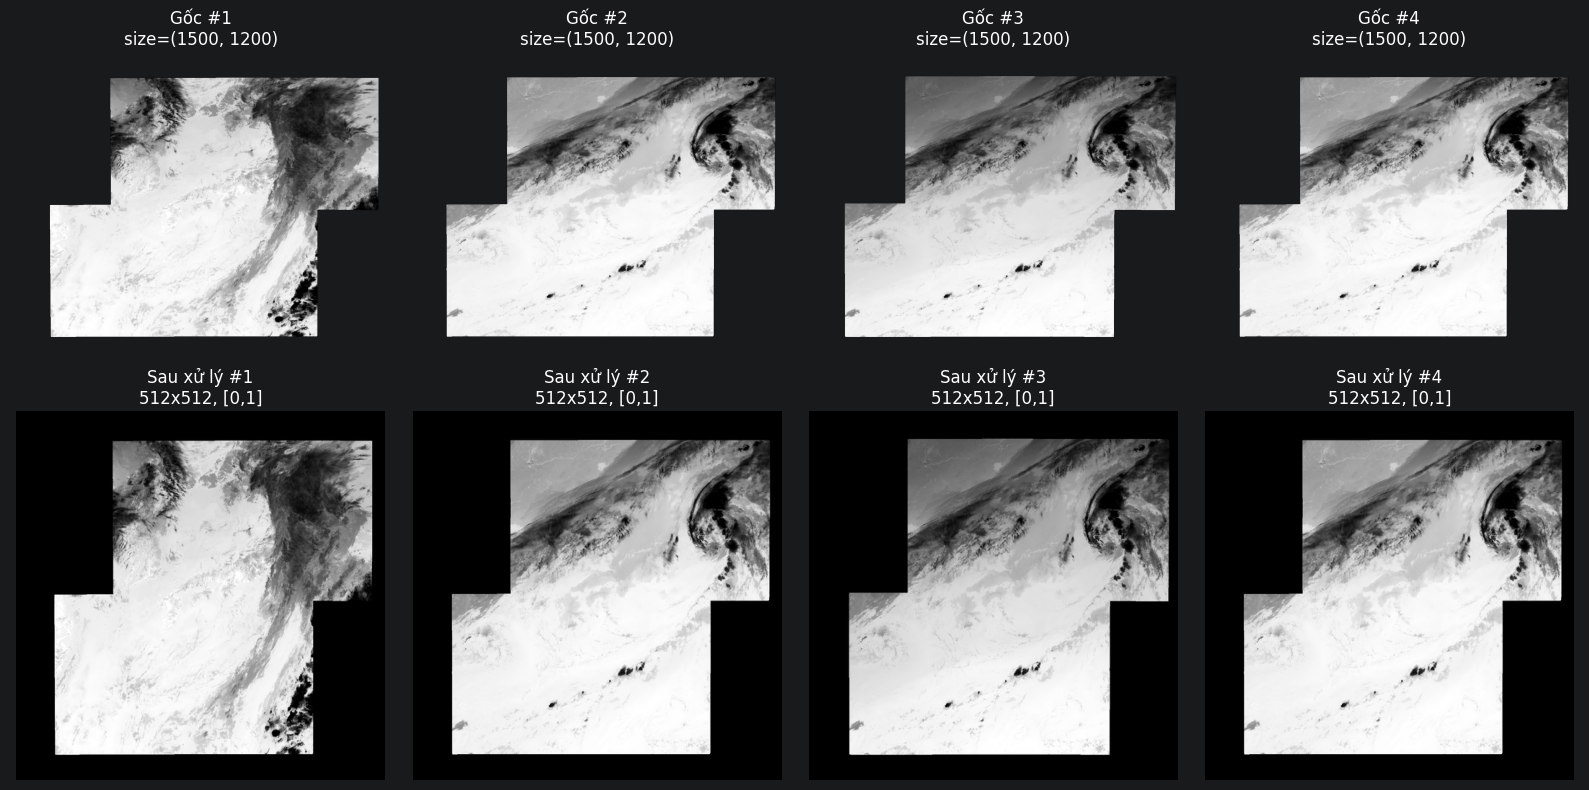

In [5]:
def preprocess_image(img: Image.Image, size=IMG_SIZE):
    '''Grayscale -> resize (LANCZOS) -> normalize [0,1] -> shape (size, size, 1)'''
    if img.mode != "L":
        img = img.convert("L")
    img = img.resize((size, size), Image.LANCZOS)
    arr = np.array(img).astype("float32") / 255.0
    arr = np.expand_dims(arr, axis=-1)  # (H, W) -> (H, W, 1)
    return arr

def preprocess_dataset(images):
    '''Áp dụng preprocess_image cho một list ảnh PIL đã load sẵn.
    Chỉ dùng cho tập nhỏ (preview/visualize), không dùng cho toàn bộ dataset lớn.'''
    return np.stack([preprocess_image(img) for img in images], axis=0)

# Xử lý thử tập preview để kiểm tra
preview_processed = preprocess_dataset(raw_preview_images)
print("Shape sau preprocessing (tập preview):", preview_processed.shape)

# So sánh trực quan ảnh trước/sau preprocessing
n_show = len(raw_preview_images)
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))
for i in range(n_show):
    axes[0, i].imshow(raw_preview_images[i], cmap="gray")
    axes[0, i].set_title(f"Gốc #{i+1}\nsize={raw_preview_images[i].size}")
    axes[0, i].axis("off")

    axes[1, i].imshow(preview_processed[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Sau xử lý #{i+1}\n{IMG_SIZE}x{IMG_SIZE}, [0,1]")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()


## 6. Dataset

Giữ nguyên hoàn toàn lớp `HimawariDataset` như bản CNN. Đây là điểm quan trọng của spec: **patchification KHÔNG được thực hiện trong `Dataset`/`DataLoader`** — `Dataset` vẫn chỉ trả về ảnh nguyên `(C, H, W) = (1, 512, 512)` như trước. Việc chia patch được thực hiện **bên trong model** (ở phần Patch Embedding), vì:

- Giữ `Dataset` đơn giản, không phải sửa lại khi đổi kiến trúc.
- Không phải lưu hàng triệu patch rời rạc trên RAM.
- Vẫn mở rộng được lên ~200,000 ảnh (lazy loading từng ảnh một, không đổi).
- Dễ thay đổi `PATCH_SIZE` sau này mà không đụng vào `Dataset`.

In [6]:
class HimawariDataset(Dataset):
    '''Dataset lazy-loading: chỉ đọc + tiền xử lý 1 ảnh khi __getitem__ được gọi.
    Phù hợp với dataset lớn (~193,000 ảnh) vì không cần giữ toàn bộ ảnh trong
    RAM/VRAM cùng lúc - chỉ cần đúng số ảnh bằng BATCH_SIZE tại một thời điểm.
    Trả về ảnh nguyên (chưa patchify) - patchify được thực hiện bên trong model.'''

    def __init__(self, image_paths, img_size=IMG_SIZE):
        self.image_paths = image_paths
        self.img_size = img_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx])
        arr = preprocess_image(img, size=self.img_size)      # (H, W, 1), float32 [0,1]
        tensor = torch.from_numpy(arr).permute(2, 0, 1)       # (H, W, 1) -> (1, H, W)
        return tensor.float()

print("Đã định nghĩa lớp HimawariDataset (lazy-loading, không patchify).")


Đã định nghĩa lớp HimawariDataset (lazy-loading, không patchify).


## 7. DataLoader

Giữ nguyên hoàn toàn logic như bản CNN — chỉ khác giá trị `BATCH_SIZE` đã đổi ở phần Configuration. Chia danh sách **đường dẫn** train thành train/validation (không chia mảng ảnh đã load, để giữ tính lazy-loading), sau đó tạo `Dataset` và `DataLoader` cho từng tập.

In [7]:
n_train_total = len(train_paths)
if n_train_total >= 5:
    train_split_paths, val_split_paths = train_test_split(
        train_paths, test_size=max(1, int(0.2 * n_train_total)), random_state=SEED
    )
else:
    print("[Cảnh báo] Dataset quá nhỏ (<5 ảnh) để chia validation có ý nghĩa thống kê.")
    print("           Dùng toàn bộ tập train làm validation (chỉ mang tính tham khảo).")
    train_split_paths, val_split_paths = train_paths, train_paths

train_dataset = HimawariDataset(train_split_paths)
val_dataset = HimawariDataset(val_split_paths)

# batch_size không vượt quá số ảnh hiện có trong từng tập
train_batch_size = min(BATCH_SIZE, len(train_dataset))
val_batch_size = min(BATCH_SIZE, len(val_dataset))

# NUM_WORKERS = 0: đặt về 0 để tránh lỗi crash kernel "-1073741795"
#   (STATUS_ILLEGAL_INSTRUCTION) khi dùng multiprocessing DataLoader (num_workers>0)
#   trong Jupyter Notebook trên Windows.
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset, batch_size=train_batch_size, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)
val_loader = DataLoader(
    val_dataset, batch_size=val_batch_size, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)

print(f"Số ảnh train: {len(train_dataset)} | Số ảnh validation: {len(val_dataset)}")
print(f"Batch size train/val: {train_batch_size}/{val_batch_size}")

# Kiểm tra nhanh 1 batch
sample_batch = next(iter(train_loader))
print("Shape 1 batch train:", sample_batch.shape)  # (B, 1, 512, 512)


Số ảnh train: 24 | Số ảnh validation: 5
Batch size train/val: 16/5
Shape 1 batch train: torch.Size([16, 1, 512, 512])


## 8. Patch Embedding

Đây là phần đầu tiên thay thế cho CNN. Gồm 3 bước:

### `patchify` / `unpatchify`

- `patchify`: chia ảnh `(B, 1, 512, 512)` thành `(B, 1024, 256)` — 1024 patch không chồng lấn, mỗi patch `16×16×1 = 256` pixel đã được flatten.
- `unpatchify`: phép nghịch đảo, ghép `(B, 1024, 256)` trở lại thành ảnh `(B, 1, 512, 512)` — dùng ở cuối Decoder.

Hai hàm này thuần túy là phép `reshape`/`permute` (không có tham số học), nên đặt độc lập ở cấp module thay vì bên trong một lớp `nn.Module`.

### `PatchEmbedding`

- **Patch Embedding**: dùng `nn.Linear(256, EMBED_DIM)` để chiếu mỗi patch (256 giá trị) sang không gian `EMBED_DIM` chiều — **không dùng Conv2D** cho bước này (đúng yêu cầu spec, khác với ViT gốc thường dùng Conv2D làm phép chiếu patch tương đương).
- **Positional Embedding**: một tham số học được `nn.Parameter` shape `(1, 1024, EMBED_DIM)`, cộng trực tiếp vào embedding của từng patch để Transformer biết được vị trí không gian của từng patch (Self-Attention tự nó không có khái niệm thứ tự/vị trí).
- **Không dùng CLS token**: vì mục tiêu là reconstruction (cần giữ đại diện cho từng patch để tái tạo lại đúng vị trí đó), không phải classification (chỉ cần 1 vector tổng hợp).

In [8]:
def patchify(imgs, patch_size=PATCH_SIZE):
    '''(B, C, H, W) -> (B, N, patch_size*patch_size*C)'''
    B, C, H, W = imgs.shape
    p = patch_size
    h, w = H // p, W // p
    x = imgs.reshape(B, C, h, p, w, p)
    x = x.permute(0, 2, 4, 3, 5, 1)          # (B, h, w, p, p, C)
    x = x.reshape(B, h * w, p * p * C)       # (B, N, patch_dim)
    return x


def unpatchify(x, patch_size=PATCH_SIZE, img_size=IMG_SIZE, channels=CHANNELS):
    '''(B, N, patch_size*patch_size*C) -> (B, C, H, W)'''
    B, N, D = x.shape
    p = patch_size
    h = w = img_size // p
    x = x.reshape(B, h, w, p, p, channels)
    x = x.permute(0, 5, 1, 3, 2, 4)          # (B, C, h, p, w, p)
    x = x.reshape(B, channels, h * p, w * p)
    return x


class PatchEmbedding(nn.Module):
    '''Patchify -> Linear projection -> + Positional Embedding.
    Không dùng Conv2D cho phép chiếu patch, không dùng CLS token.'''

    def __init__(self, patch_size=PATCH_SIZE, channels=CHANNELS,
                 embed_dim=EMBED_DIM, num_patches=NUM_PATCHES):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Linear(patch_size * patch_size * channels, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        patches = patchify(x, self.patch_size)   # (B, N, patch_dim)
        tokens = self.proj(patches)               # (B, N, embed_dim)
        tokens = tokens + self.pos_embed           # + thông tin vị trí
        return tokens, patches


# Kiểm tra nhanh với batch vừa lấy ở phần DataLoader
_patch_embed_test = PatchEmbedding().to(device)
_tokens_test, _patches_test = _patch_embed_test(sample_batch.to(device))
print("Patch shape:     ", tuple(_patches_test.shape))   # (B, 1024, 256)
print("Embedding shape: ", tuple(_tokens_test.shape))    # (B, 1024, 384)


Patch shape:      (16, 1024, 256)
Embedding shape:  (16, 1024, 384)


## 9. Transformer Encoder

### LayerNorm thay vì BatchNorm

Bản CNN dùng `BatchNorm2d` sau `Conv2D(128)` và `Conv2D(256)`, chuẩn hóa theo **từng channel, trên toàn bộ batch + không gian ảnh**. Với Transformer, ta dùng **`LayerNorm`** thay vì `BatchNorm`, vì:

- `BatchNorm` chuẩn hóa dựa trên thống kê (mean/variance) tính **trên toàn batch** — hoạt động tốt với CNN vì batch thường đủ lớn và shape ảnh cố định, nhưng với Transformer, `BatchNorm` làm mô hình phụ thuộc vào `BATCH_SIZE` lúc train (thống kê không ổn định khi batch nhỏ hoặc thay đổi giữa train/inference).
- `LayerNorm` chuẩn hóa dựa trên thống kê tính **trên từng token riêng lẻ** (trên chiều `EMBED_DIM`), độc lập với batch size và độc lập giữa các token — phù hợp hơn với dữ liệu dạng chuỗi (sequence) như token/patch, nơi mỗi vị trí có thể có phân phối giá trị khác nhau.
- Đây là lý do mọi kiến trúc Transformer (từ NLP đến ViT) đều dùng `LayerNorm`, không dùng `BatchNorm`.

### Kiến trúc mỗi Transformer Block (pre-norm)

```
x → LayerNorm → Multi-Head Self-Attention → (+residual) →
    LayerNorm → MLP (Linear → GELU → Linear) → (+residual)
```

Toàn bộ `NUM_PATCHES = 1024` patch (không bỏ patch nào, không masking) được đưa qua `ENCODER_DEPTH = 8` block liên tiếp. Self-Attention cho phép mỗi patch "nhìn thấy" toàn bộ 1023 patch còn lại ngay từ block đầu tiên — khác với CNN vốn có receptive field cục bộ, tăng dần theo độ sâu mạng.

Output cuối cùng là **latent representation dạng chuỗi đầy đủ** `(B, 1024, EMBED_DIM)` — không nén thành một vector duy nhất, để giữ thông tin không gian cần thiết cho việc tái tạo ảnh ở Decoder.

In [9]:
class TransformerBlock(nn.Module):
    '''LayerNorm -> Multi-Head Self-Attention -> residual ->
    LayerNorm -> MLP -> residual (pre-norm Transformer block).'''

    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim),
        )

    def forward(self, x):
        normed = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed, need_weights=False)
        x = x + attn_out                 # residual connection quanh Attention
        x = x + self.mlp(self.norm2(x))  # residual connection quanh MLP
        return x


class Encoder(nn.Module):
    '''Patch Embedding -> N Transformer Block -> LayerNorm cuối.
    Nhận TOÀN BỘ patch, không masking, không CLS token.'''

    def __init__(self):
        super().__init__()
        self.patch_embed = PatchEmbedding(PATCH_SIZE, CHANNELS, EMBED_DIM, NUM_PATCHES)
        self.blocks = nn.ModuleList(
            [TransformerBlock(EMBED_DIM, NUM_HEADS, MLP_RATIO) for _ in range(ENCODER_DEPTH)]
        )
        self.norm = nn.LayerNorm(EMBED_DIM)

    def forward(self, x, return_intermediate=False):
        tokens, patches = self.patch_embed(x)   # (B, 1024, EMBED_DIM)
        embedded = tokens
        for block in self.blocks:
            tokens = block(tokens)
        latent = self.norm(tokens)              # (B, 1024, EMBED_DIM) <-- Latent Representation
        if return_intermediate:
            return latent, patches, embedded
        return latent


encoder = Encoder().to(device)
print(encoder)


Encoder(
  (patch_embed): PatchEmbedding(
    (proj): Linear(in_features=256, out_features=384, bias=True)
  )
  (blocks): ModuleList(
    (0-7): 8 x TransformerBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=384, out_features=384, bias=True)
      )
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): Sequential(
        (0): Linear(in_features=384, out_features=1536, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=1536, out_features=384, bias=True)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
)


## 10. Transformer Decoder

Luồng của Decoder:

```
Latent Representation (B, 1024, EMBED_DIM)
  → Decoder Embedding (Linear: EMBED_DIM -> DECODER_EMBED_DIM)
  → + Decoder Positional Embedding
  → N Transformer Block (DECODER_DEPTH khối, nhỏ hơn Encoder)
  → LayerNorm
  → Reconstruction Head (Linear: DECODER_EMBED_DIM -> 256)
  → Patch Predictions (B, 1024, 256)
  → Unpatchify
  → Sigmoid
  → Ảnh tái tạo (B, 1, 512, 512)
```

- **Decoder Embedding + Decoder Positional Embedding riêng**: vì Decoder hoạt động ở một không gian chiều khác (`DECODER_EMBED_DIM = 192` thay vì `EMBED_DIM = 384`), cần positional embedding học riêng cho không gian này (không dùng chung với Encoder).
- **Decoder nhẹ hơn Encoder** (`DECODER_DEPTH = 4` so với `ENCODER_DEPTH = 8`, `DECODER_EMBED_DIM = 192` so với `EMBED_DIM = 384`) — đúng tinh thần thiết kế bất đối xứng của MAE: phần học biểu diễn (Encoder) cần mạnh, phần tái tạo pixel (Decoder) không cần phức tạp bằng.
- **Reconstruction Head**: `nn.Linear(DECODER_EMBED_DIM, 256)` ánh xạ mỗi token trở lại đúng 256 giá trị pixel của patch tương ứng.
- **`Sigmoid`** ở cuối: đưa giá trị pixel về đúng khoảng `[0, 1]`, khớp với dữ liệu đầu vào đã normalize — giống hệt vai trò của `sigmoid` ở lớp `conv_out` cuối cùng trong Decoder CNN trước đây.
- Decoder tái tạo **toàn bộ 1024 patch** — không có patch nào bị bỏ qua hay chỉ tái tạo một phần (khác với MAE gốc chỉ cần tái tạo patch bị che).

In [10]:
class Decoder(nn.Module):
    '''Decoder Embedding -> + Decoder Positional Embedding ->
    N Transformer Block (nhẹ hơn Encoder) -> LayerNorm ->
    Reconstruction Head -> Unpatchify -> Sigmoid.
    Tái tạo TOÀN BỘ 1024 patch, không masking.'''

    def __init__(self):
        super().__init__()
        self.decoder_embed = nn.Linear(EMBED_DIM, DECODER_EMBED_DIM)
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, NUM_PATCHES, DECODER_EMBED_DIM))
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)

        self.blocks = nn.ModuleList(
            [TransformerBlock(DECODER_EMBED_DIM, DECODER_NUM_HEADS, MLP_RATIO)
             for _ in range(DECODER_DEPTH)]
        )
        self.norm = nn.LayerNorm(DECODER_EMBED_DIM)
        self.decoder_pred = nn.Linear(DECODER_EMBED_DIM, PATCH_SIZE * PATCH_SIZE * CHANNELS)

    def forward(self, latent, return_intermediate=False):
        x = self.decoder_embed(latent)          # (B, 1024, DECODER_EMBED_DIM)
        x = x + self.decoder_pos_embed
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        patch_pred = self.decoder_pred(x)        # (B, 1024, 256) <-- Reconstructed patches
        img = unpatchify(patch_pred, PATCH_SIZE, IMG_SIZE, CHANNELS)
        img = torch.sigmoid(img)                 # (B, 1, 512, 512), giá trị trong [0,1]
        if return_intermediate:
            return img, patch_pred
        return img


decoder = Decoder().to(device)
print(decoder)


Decoder(
  (decoder_embed): Linear(in_features=384, out_features=192, bias=True)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
      )
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): Sequential(
        (0): Linear(in_features=192, out_features=768, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=768, out_features=192, bias=True)
      )
    )
  )
  (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=True)
  (decoder_pred): Linear(in_features=192, out_features=256, bias=True)
)


## 11. Autoencoder

Ghép `Encoder` và `Decoder` thành lớp `Autoencoder` hoàn chỉnh — giữ nguyên interface như bản CNN (`autoencoder.encoder`, `autoencoder.decoder` vẫn truy cập được độc lập để lấy latent hoặc decode riêng).

### So sánh hai kiến trúc

```
CNN Autoencoder (cũ):
Image → Conv2D → MaxPooling → Conv2D → BatchNorm → ... → Latent (feature map) → ConvTranspose2D → ... → Image

Vision Transformer Autoencoder (mới):
Image → Patchify → Patch Embedding → + Positional Embedding
      → Transformer Encoder (Self-Attention, toàn bộ patch) → Latent Tokens
      → Transformer Decoder → Patch Reconstruction → Unpatchify → Image
```

**Vì sao ViT phù hợp hơn để học quan hệ không gian của ảnh vệ tinh?** CNN chỉ "nhìn" được một vùng cục bộ (receptive field) tại mỗi lớp, phải xếp chồng nhiều lớp mới dần dần bao quát được toàn ảnh. Với ảnh mây/bão có cấu trúc trải rộng và các vùng ở xa nhau vẫn có liên hệ khí tượng (ví dụ hoàn lưu của một cơn bão trải khắp ảnh), Self-Attention cho phép mô hình học được mối quan hệ giữa **hai patch bất kỳ, dù ở xa nhau**, ngay từ block Transformer đầu tiên — không cần đợi mạng đủ sâu như CNN.

In [11]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed


autoencoder = Autoencoder().to(device)

n_params_enc = sum(p.numel() for p in autoencoder.encoder.parameters())
n_params_dec = sum(p.numel() for p in autoencoder.decoder.parameters())
n_params_total = sum(p.numel() for p in autoencoder.parameters())
n_trainable = sum(p.numel() for p in autoencoder.parameters() if p.requires_grad)

print(f"Số tham số Encoder:      {n_params_enc:,}")
print(f"Số tham số Decoder:      {n_params_dec:,}")
print(f"Tổng số tham số:         {n_params_total:,}")
print(f"Số tham số có thể train: {n_trainable:,}")


Số tham số Encoder:      14,688,384
Số tham số Decoder:      2,099,776
Tổng số tham số:         16,788,160
Số tham số có thể train: 16,788,160


## 12. Model Shape Test

Kiểm tra đầy đủ shape qua từng bước của pipeline, dùng input ngẫu nhiên `(1, 1, 512, 512)` — bắt buộc theo spec để xác nhận kiến trúc lắp ráp đúng trước khi bước vào training tốn thời gian.

In [12]:
with torch.no_grad():
    test_input = torch.randn(1, CHANNELS, IMG_SIZE, IMG_SIZE).to(device)

    test_latent, test_patches, test_embedded = autoencoder.encoder(test_input, return_intermediate=True)
    test_output, test_patch_pred = autoencoder.decoder(test_latent, return_intermediate=True)

print("Input shape:               ", tuple(test_input.shape))       # (1, 1, 512, 512)
print("Patch shape:                ", tuple(test_patches.shape))     # (1, 1024, 256)
print("Embedding shape:            ", tuple(test_embedded.shape))    # (1, 1024, 384)
print("Latent shape:                ", tuple(test_latent.shape))      # (1, 1024, 384)
print("Reconstructed patch shape:  ", tuple(test_patch_pred.shape))  # (1, 1024, 256)
print("Output shape:                ", tuple(test_output.shape))      # (1, 1, 512, 512)

assert tuple(test_output.shape) == (1, CHANNELS, IMG_SIZE, IMG_SIZE), "Output shape không khớp yêu cầu!"
print("\nOutput shape khớp đúng yêu cầu (1, 1, 512, 512).")


Input shape:                (1, 1, 512, 512)
Patch shape:                 (1, 1024, 256)
Embedding shape:             (1, 1024, 384)
Latent shape:                 (1, 1024, 384)
Reconstructed patch shape:   (1, 1024, 256)
Output shape:                 (1, 1, 512, 512)

Output shape khớp đúng yêu cầu (1, 1, 512, 512).


In [14]:
import os
if os.path.exists("training_checkpoint.pth"):
    os.remove("training_checkpoint.pth")
    print("Đã xoá checkpoint CNN cũ.")
if os.path.exists("encoder.pth"):
    os.remove("encoder.pth")
    print ("Đã xóa encoder CNN cũ.")
if os.path.exists("decoder.pth"):
    os.remove("decoder.pth")
    print("Đã xóa decoder CNN cũ.")

Đã xoá checkpoint CNN cũ.
Đã xóa encoder CNN cũ.
Đã xóa decoder CNN cũ.


## 13. Training

### Toán học của reconstruction loss

Loss chính là **MSE (Mean Squared Error)** giữa ảnh gốc $x$ và ảnh tái tạo $\hat{x}$, tính trung bình trên toàn bộ pixel:

$$
\mathcal{L}_{MSE}(x, \hat{x}) = \frac{1}{N} \sum_{i=1}^{N} (x_i - \hat{x}_i)^2
$$

trong đó $N$ là tổng số pixel (ở đây $N = 512 \times 512 = 262{,}144$ pixel/ảnh). Loss được tính trên **toàn bộ ảnh** (không phải chỉ trên patch bị che như MAE gốc — vì notebook này không dùng masking).

### Bổ sung L1 và L2 regularization (giữ nguyên như bản CNN)

$$
\mathcal{L}_{total} = \mathcal{L}_{MSE}(x, \hat{x}) \;+\; \lambda_1 \sum_{w \in \theta} |w| \;+\; \lambda_2 \sum_{w \in \theta} w^2
$$

- $\lambda_1 \sum |w|$ (**L1**) được cộng thủ công vào loss trong vòng lặp training — hàm `l1_penalty` tính trên **toàn bộ tham số của model**, áp dụng như nhau dù model là CNN hay Transformer.
- $\lambda_2 \sum w^2$ (**L2 / weight decay**) vẫn được PyTorch tính tự động bên trong optimizer Adam qua `weight_decay=L2_WEIGHT_DECAY`.

### Vòng lặp training (giữ nguyên logic)

Huấn luyện theo mini-batch, `EarlyStopping` thủ công (theo dõi `val_loss`), lưu checkpoint sau mỗi epoch để có thể resume, và khôi phục trọng số tốt nhất sau khi kết thúc — không có thay đổi logic nào so với bản CNN.

### Mixed Precision Training (AMP)

Vẫn dùng `torch.cuda.amp.autocast()` + `GradScaler` như bản CNN. Với Transformer, AMP giúp giảm đáng kể VRAM cho ma trận attention `(B, NUM_HEADS, 1024, 1024)` — đây là lý do quan trọng giúp `BATCH_SIZE = 16` (đã giảm ở Configuration) vẫn có thể tăng lại phần nào khi chạy trên GPU có Tensor Cores.

In [15]:
optimizer = optim.Adam(autoencoder.parameters(), lr=LEARNING_RATE, weight_decay=L2_WEIGHT_DECAY)
criterion = nn.MSELoss()

# AMP: autocast tự động chọn FP16 cho các phép toán an toàn (giảm VRAM, tăng tốc
# trên GPU có Tensor Cores), GradScaler chống underflow gradient khi tính ở FP16.
# Tự tắt (enabled=False) nếu chạy trên CPU vì AMP chỉ có lợi trên GPU.
USE_AMP = (device.type == "cuda")
scaler = GradScaler(enabled=USE_AMP)

def l1_penalty(model, lam):
    '''Tính số hạng L1 regularization: lambda1 * sum(|w|) trên toàn bộ trọng số.'''
    l1 = sum(p.abs().sum() for p in model.parameters())
    return lam * l1

# Đường dẫn file checkpoint - lưu TOÀN BỘ trạng thái training để có thể resume
CHECKPOINT_PATH = "training_checkpoint.pth"

train_losses, val_losses = [], []
val_ssim_scores = []
best_val_loss = float("inf")
best_state_dict = None
epochs_no_improve = 0
start_epoch = 1

# Nếu đã có checkpoint từ lần chạy trước (ví dụ bị tắt máy giữa chừng), tự động
# load lại toàn bộ trạng thái và tiếp tục từ đúng epoch bị dừng.
if os.path.exists(CHECKPOINT_PATH):
    print(f"Tìm thấy checkpoint tại '{CHECKPOINT_PATH}' - đang khôi phục để tiếp tục training...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    autoencoder.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"] + 1
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]
    val_ssim_scores = checkpoint["val_ssim_scores"]
    best_val_loss = checkpoint["best_val_loss"]
    best_state_dict = checkpoint["best_state_dict"]
    epochs_no_improve = checkpoint["epochs_no_improve"]
    if "scaler_state_dict" in checkpoint:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])
    if "rng_state" in checkpoint:
        random.setstate(checkpoint["rng_state"]["python"])
        np.random.set_state(checkpoint["rng_state"]["numpy"])
        torch.set_rng_state(checkpoint["rng_state"]["torch_cpu"].cpu().byte())
        if checkpoint["rng_state"]["torch_cuda"] is not None and torch.cuda.is_available():
            torch.cuda.set_rng_state_all(checkpoint["rng_state"]["torch_cuda"])
    else:
        print("[Cảnh báo] Checkpoint cũ không có rng_state - thứ tự shuffle sau resume "
              "sẽ không khớp hoàn toàn với lần chạy gốc (không ảnh hưởng tính đúng đắn, "
              "chỉ khác biệt nhỏ so với chạy liên tục không gián đoạn).")
    print(f"Đã khôi phục xong - tiếp tục training từ epoch {start_epoch}/{EPOCHS} "
          f"(best_val_loss hiện tại: {best_val_loss:.6f}).")
else:
    print("Không tìm thấy checkpoint - bắt đầu training từ epoch 1.")

for epoch in range(start_epoch, EPOCHS + 1):
    # ----- Training -----
    autoencoder.train()
    running_loss = 0.0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", unit="batch", leave=True)
    for batch in train_bar:
        batch = batch.to(device)

        optimizer.zero_grad()
        with autocast(enabled=USE_AMP):
            outputs = autoencoder(batch)
            loss = criterion(outputs, batch) + l1_penalty(autoencoder, L1_LAMBDA)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * batch.size(0)
        train_bar.set_postfix(batch_loss=f"{loss.item():.6f}")
    train_loss = running_loss / len(train_dataset)

    # ----- Validation -----
    autoencoder.eval()
    running_val_loss = 0.0
    running_val_ssim = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            with autocast(enabled=USE_AMP):
                outputs = autoencoder(batch)
                loss = criterion(outputs, batch)  # không cộng L1 khi đánh giá validation
            running_val_loss += loss.item() * batch.size(0)

            batch_ssim = ssim_gpu(outputs.float(), batch.float(), data_range=1.0, size_average=False)
            running_val_ssim += batch_ssim.sum().item()
    val_loss = running_val_loss / len(val_dataset)
    val_ssim = running_val_ssim / len(val_dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_ssim_scores.append(val_ssim)

    print(f"Epoch {epoch:4d}/{EPOCHS} - train_loss: {train_loss:.6f} - val_loss: {val_loss:.6f} - val_ssim: {val_ssim:.4f}")

    # ----- Early stopping thủ công -----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = {k: v.clone() for k, v in autoencoder.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # Lưu checkpoint sau MỖI epoch
    torch.save({
        "epoch": epoch,
        "model_state_dict": autoencoder.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_ssim_scores": val_ssim_scores,
        "best_val_loss": best_val_loss,
        "best_state_dict": best_state_dict,
        "epochs_no_improve": epochs_no_improve,
        "scaler_state_dict": scaler.state_dict(),
        "rng_state": {
            "python": random.getstate(),
            "numpy": np.random.get_state(),
            "torch_cpu": torch.get_rng_state(),
            "torch_cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        },
    }, CHECKPOINT_PATH)

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping tại epoch {epoch} (val_loss không cải thiện sau {EARLY_STOPPING_PATIENCE} epoch).")
        break

# Khôi phục trọng số tốt nhất
if best_state_dict is not None:
    autoencoder.load_state_dict(best_state_dict)
    print(f"\nĐã khôi phục trọng số tốt nhất (val_loss = {best_val_loss:.6f}).")

# Training đã hoàn tất hẳn - xoá checkpoint để lần chạy tiếp theo không bị nhầm resume.
if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)
    print(f"Đã xoá checkpoint tạm '{CHECKPOINT_PATH}' vì training đã hoàn tất.")


Không tìm thấy checkpoint - bắt đầu training từ epoch 1.


C:\Users\quang\AppData\Local\Temp\ipykernel_2592\4261656629.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)


Epoch 1/100 [Train]:   0%|          | 0/2 [00:00<?, ?batch/s]

C:\Users\quang\AppData\Local\Temp\ipykernel_2592\4261656629.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
C:\Users\quang\AppData\Local\Temp\ipykernel_2592\4261656629.py:83: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch    1/100 - train_loss: 4.175398 - val_loss: 0.179062 - val_ssim: 0.0371


...

Epoch   98/100 - train_loss: 0.141656 - val_loss: 0.006167 - val_ssim: 0.4162


Epoch 99/100 [Train]:   0%|          | 0/2 [00:00<?, ?batch/s]

Epoch   99/100 - train_loss: 0.140340 - val_loss: 0.006028 - val_ssim: 0.4203


Epoch 100/100 [Train]:   0%|          | 0/2 [00:00<?, ?batch/s]

Epoch  100/100 - train_loss: 0.139127 - val_loss: 0.006025 - val_ssim: 0.4153

Đã khôi phục trọng số tốt nhất (val_loss = 0.006025).
Đã xoá checkpoint tạm 'training_checkpoint.pth' vì training đã hoàn tất.


## 14. Evaluation

Giữ nguyên hoàn toàn phương pháp đánh giá như bản CNN (MSE, MAE, PSNR, SSIM) — các metric này chỉ so sánh ảnh gốc và ảnh tái tạo ở mức pixel, không phụ thuộc vào kiến trúc model bên trong.

### Công thức các metric

- **MSE**: $\mathcal{L}_{MSE} = \frac{1}{N}\sum (x_i - \hat{x}_i)^2$ — càng nhỏ càng tốt.
- **MAE** (Mean Absolute Error): $\mathcal{L}_{MAE} = \frac{1}{N}\sum |x_i - \hat{x}_i|$ — càng nhỏ càng tốt, ít nhạy với outlier hơn MSE.
- **PSNR** (Peak Signal-to-Noise Ratio), đơn vị dB:

$$
PSNR = 10 \cdot \log_{10}\left(\frac{MAX^2}{MSE}\right)
$$

  với $MAX = 1$ (vì ảnh đã normalize về $[0,1]$).

- **SSIM** (Structural Similarity Index):

$$
SSIM(x, \hat{x}) = \frac{(2\mu_x \mu_{\hat{x}} + c_1)(2\sigma_{x\hat{x}} + c_2)}{(\mu_x^2 + \mu_{\hat{x}}^2 + c_1)(\sigma_x^2 + \sigma_{\hat{x}}^2 + c_2)}
$$

### Similarity theo phần trăm

$$
\text{Similarity}(\%) = \max(0, SSIM(x, \hat{x})) \times 100\%
$$

Lưu ý (giữ nguyên như bản CNN): SSIM×100% **không phải** phần trăm pixel giống hệt nhau, mà là cách biểu diễn điểm tương đồng cấu trúc dưới dạng phần trăm.

In [16]:
autoencoder.eval()

# Dùng tập test nếu có, nếu không thì dùng tập validation
if len(test_paths) > 0:
    eval_paths = test_paths
    eval_source = "tập test"
else:
    eval_paths = val_split_paths
    eval_source = "tập validation (do không có ảnh test)"

print(f"Đánh giá trên {eval_source}, gồm {len(eval_paths)} ảnh.")

eval_dataset = HimawariDataset(eval_paths)
eval_loader = DataLoader(eval_dataset, batch_size=min(BATCH_SIZE, len(eval_dataset)), shuffle=False)

originals_list, reconstructed_list = [], []
with torch.no_grad():
    for batch in eval_loader:
        batch = batch.to(device)
        outputs = autoencoder(batch)
        originals_list.append(batch.cpu().numpy())
        reconstructed_list.append(outputs.cpu().numpy())

originals = np.concatenate(originals_list, axis=0)          # (N, 1, 512, 512)
reconstructed = np.concatenate(reconstructed_list, axis=0)  # (N, 1, 512, 512)
reconstructed = np.clip(reconstructed, 0, 1)

# ----- Tính các metric -----
mse_val = np.mean((originals - reconstructed) ** 2)
mae_val = np.mean(np.abs(originals - reconstructed))

psnr_values, ssim_values = [], []
for i in range(len(originals)):
    orig_img = originals[i, 0]
    recon_img = reconstructed[i, 0]
    psnr_values.append(psnr_metric(orig_img, recon_img, data_range=1.0))
    ssim_values.append(ssim_metric(orig_img, recon_img, data_range=1.0))

psnr_val = float(np.mean(psnr_values))
ssim_val = float(np.mean(ssim_values))
similarity_percent = max(0.0, ssim_val) * 100

print(f"MSE trung bình:        {mse_val:.6f}")
print(f"MAE trung bình:        {mae_val:.6f}")
print(f"PSNR trung bình:       {psnr_val:.2f} dB")
print(f"SSIM trung bình:       {ssim_val:.4f}")
print(f"Similarity (theo %):   {similarity_percent:.2f}%")


Đánh giá trên tập test, gồm 8 ảnh.
MSE trung bình:        0.007144
MAE trung bình:        0.057091
PSNR trung bình:       21.49 dB
SSIM trung bình:       0.3574
Similarity (theo %):   35.74%


## 15. Visualization

Hiển thị đúng luồng spec yêu cầu: **Ảnh gốc → Patch representation → Latent representation → Ảnh tái tạo**.

### Biểu đồ training/validation loss

Cách diễn giải giữ nguyên như bản CNN: loss giảm dần nghĩa là model học tốt hơn; nếu `train_loss` tiếp tục giảm nhưng `val_loss` tăng trở lại thì đó là dấu hiệu overfitting.

### Patch representation

Vì hiển thị hết 1024 patch sẽ quá tải, dùng **grid đại diện 8×8** (64 patch đầu tiên) để minh họa việc ảnh đã được chia nhỏ như thế nào trước khi vào Encoder.

### Latent representation

Latent giờ có dạng chuỗi `(1024, EMBED_DIM)` thay vì feature map không gian `(64, 64, 256)` như CNN cũ. Để vẫn hiển thị được dưới dạng ảnh 2D, ta lấy **giá trị trung bình theo chiều EMBED_DIM của mỗi token**, sau đó xếp lại đúng theo lưới không gian `32×32` (vì `512/16 = 32` patch mỗi cạnh) — đây là cách xấp xỉ trực quan hoá tương tự "mean activation map" đã dùng ở bản CNN, chỉ khác kích thước lưới (32×32 thay vì 64×64).

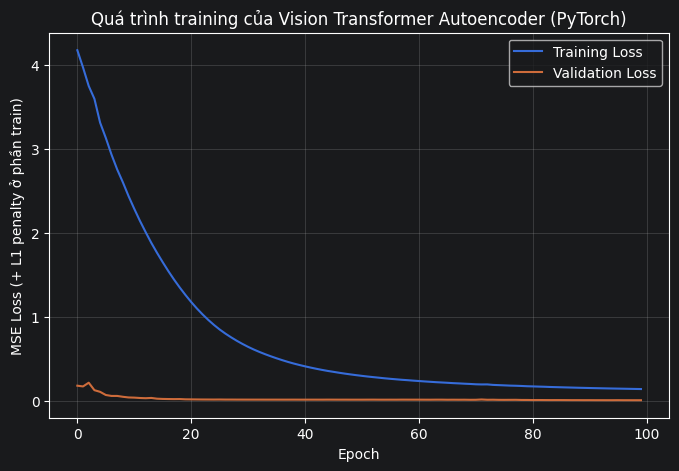

Loss cuối cùng - train: 0.139127 | val: 0.006025
Loss thấp nhất - train: 0.139127 | val: 0.006025


In [17]:
# --- Biểu đồ Training / Validation Loss ---
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (+ L1 penalty ở phần train)")
plt.title("Quá trình training của Vision Transformer Autoencoder (PyTorch)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Loss cuối cùng - train: {train_losses[-1]:.6f} | val: {val_losses[-1]:.6f}")
print(f"Loss thấp nhất - train: {min(train_losses):.6f} | val: {min(val_losses):.6f}")


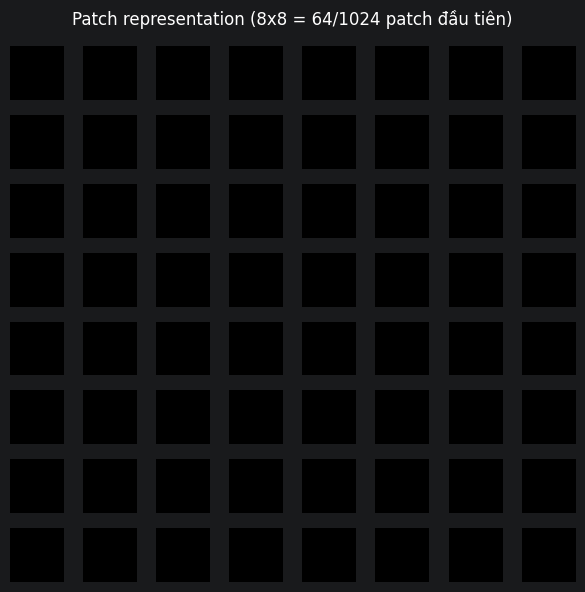

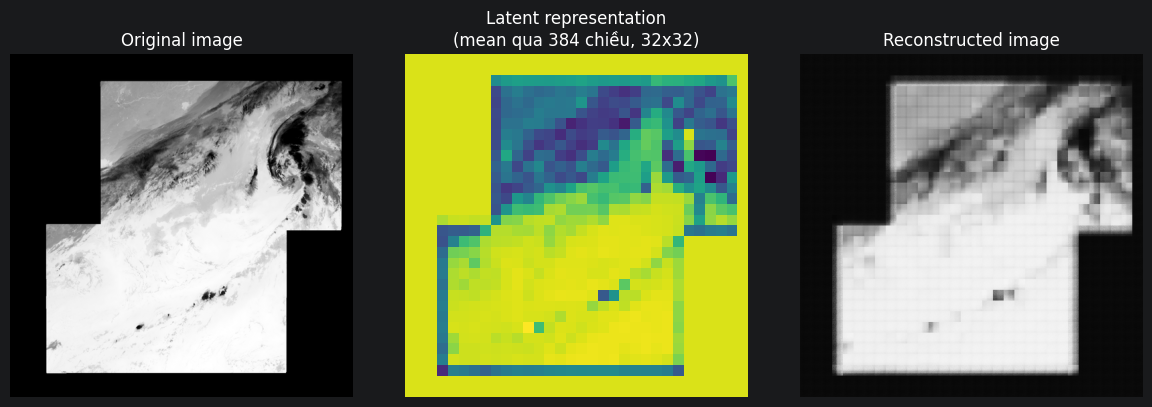

In [18]:
def visualize(img_tensor, encoder, decoder):
    '''Hiển thị: Original -> Patch representation (grid 8x8) ->
    Latent representation (mean qua EMBED_DIM, xếp lưới 32x32) -> Reconstructed.
    img_tensor: tensor shape (1, H, W) hoặc (H, W) - một ảnh đã preprocess.'''
    encoder.eval()
    decoder.eval()

    if img_tensor.dim() == 2:
        img_tensor = img_tensor.unsqueeze(0)
    batch = img_tensor.unsqueeze(0).to(device)  # (1, 1, H, W)

    with torch.no_grad():
        latent, patches, _ = encoder(batch, return_intermediate=True)  # latent: (1,1024,EMBED_DIM)
        reconstructed = decoder(latent)                                  # (1, 1, H, W)

    original_np = batch.cpu().numpy()[0, 0]
    grid_size = IMG_SIZE // PATCH_SIZE  # 32
    latent_mean_np = latent.cpu().numpy()[0].mean(axis=-1).reshape(grid_size, grid_size)
    reconstructed_np = np.clip(reconstructed.cpu().numpy()[0, 0], 0, 1)

    # Grid đại diện 8x8 patch đầu tiên (64/1024 patch)
    patches_np = patches.cpu().numpy()[0]  # (1024, 256)
    n_grid = 8
    fig_p, axes_p = plt.subplots(n_grid, n_grid, figsize=(6, 6))
    for i in range(n_grid * n_grid):
        r, c = divmod(i, n_grid)
        axes_p[r, c].imshow(patches_np[i].reshape(PATCH_SIZE, PATCH_SIZE), cmap="gray", vmin=0, vmax=1)
        axes_p[r, c].axis("off")
    fig_p.suptitle(f"Patch representation (8x8 = 64/{NUM_PATCHES} patch đầu tiên)")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(original_np, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Original image")
    axes[0].axis("off")

    axes[1].imshow(latent_mean_np, cmap="viridis")
    axes[1].set_title(f"Latent representation\n(mean qua {EMBED_DIM} chiều, {grid_size}x{grid_size})")
    axes[1].axis("off")

    axes[2].imshow(reconstructed_np, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("Reconstructed image")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

# Demo hàm visualize trên 1 ảnh mẫu từ tập đánh giá
sample_tensor = torch.from_numpy(originals[0])  # (1, H, W)
visualize(sample_tensor, autoencoder.encoder, autoencoder.decoder)


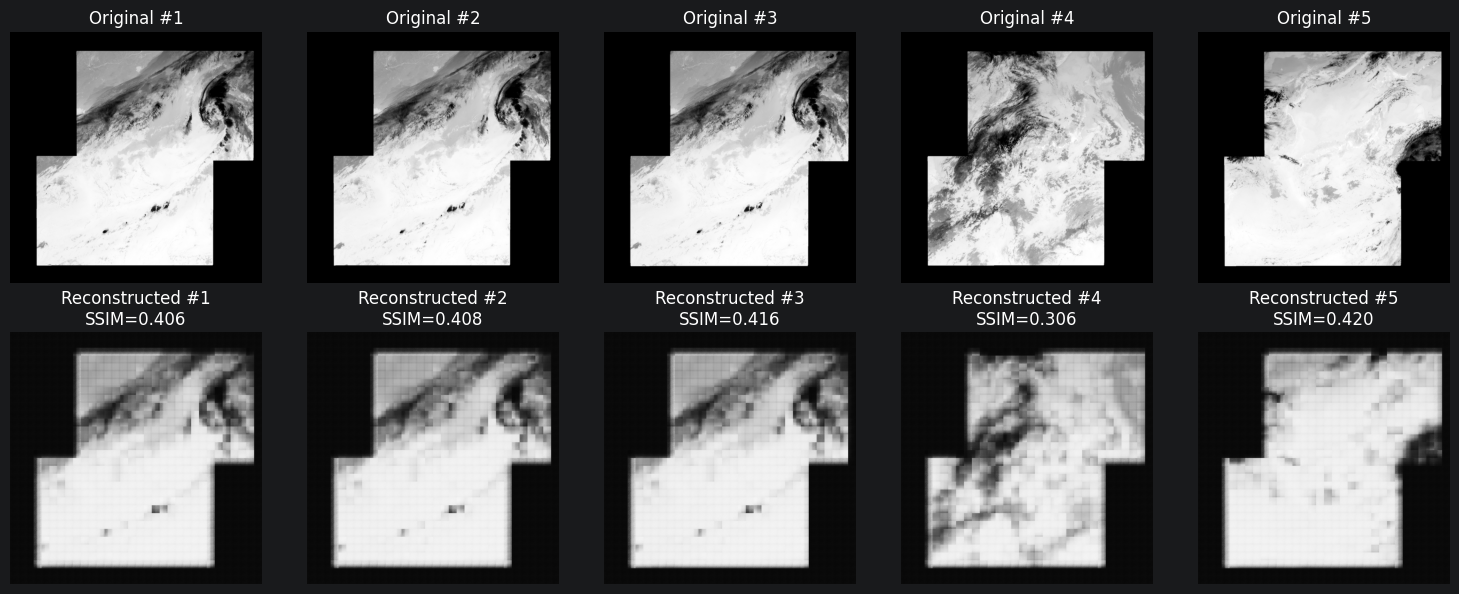

In [19]:
# --- So sánh ít nhất 5 cặp ảnh Original / Reconstructed ---
n_show = min(5, len(originals))
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i in range(n_show):
    axes[0, i].imshow(originals[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"Original #{i+1}")
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructed[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Reconstructed #{i+1}\nSSIM={ssim_values[i]:.3f}")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()


## 16. Save model

Giữ nguyên hoàn toàn logic như bản CNN: lưu `state_dict` (chỉ trọng số) của `encoder`, `decoder`, và `autoencoder` bằng `torch.save()` — cách làm này không phụ thuộc vào kiến trúc bên trong (CNN hay Transformer).

In [20]:
torch.save(autoencoder.encoder.state_dict(), "encoder.pth")
torch.save(autoencoder.decoder.state_dict(), "decoder.pth")
torch.save(autoencoder.state_dict(), "autoencoder.pth")

print("Đã lưu: encoder.pth, decoder.pth, autoencoder.pth")


Đã lưu: encoder.pth, decoder.pth, autoencoder.pth


## 17. Load model

Giữ nguyên hoàn toàn logic như bản CNN: khởi tạo lại kiến trúc model (`Encoder`, `Decoder`, `Autoencoder` — giờ là ViT thay vì CNN), sau đó dùng `torch.load()` + `load_state_dict()` để nạp lại trọng số đã lưu, rồi chạy thử lại trên 1 ảnh để xác nhận.

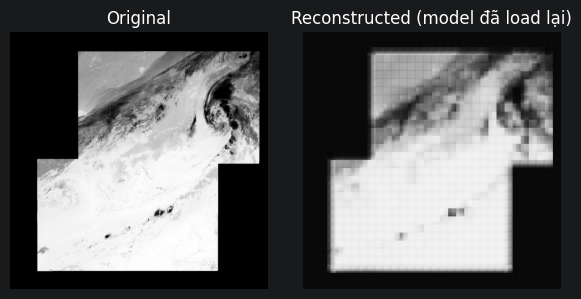

Model load lại hoạt động đúng như mong đợi.


In [21]:
loaded_encoder = Encoder().to(device)
loaded_decoder = Decoder().to(device)
loaded_autoencoder = Autoencoder().to(device)

loaded_encoder.load_state_dict(torch.load("encoder.pth", map_location=device))
loaded_decoder.load_state_dict(torch.load("decoder.pth", map_location=device))
loaded_autoencoder.load_state_dict(torch.load("autoencoder.pth", map_location=device))

loaded_encoder.eval()
loaded_decoder.eval()
loaded_autoencoder.eval()

# Kiểm tra bằng cách chạy lại trên 1 ảnh mẫu
sample_batch = torch.from_numpy(originals[:1]).to(device)
with torch.no_grad():
    sample_reconstructed = loaded_autoencoder(sample_batch)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(sample_batch.cpu().numpy()[0, 0], cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(np.clip(sample_reconstructed.cpu().numpy()[0, 0], 0, 1), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Reconstructed (model đã load lại)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Model load lại hoạt động đúng như mong đợi.")
